In [47]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np 

**Zadanie 1**

Dla zbioru danych `zamowienia.csv` wykonaj:
* 1.1 Wczytaj dane i sprawdź czy są w nim jakieś wartości brakujące.
* 1.2 W kolumnie `Sprzedawca` zastąp losowo 10% wartości wartością 'BRAK'. (zobacz funkcje pseudolosowe w bibliotece pandas lub numpy oraz wykorzystaj ćwiczenia z zajęć poprzednich z indeksowaniem danych w ramkach/seriach)
* 1.3 W kolumnie `idZamowienia` zastąp 5% wartości wartością `np.nan`.
* 1.4 W kolumnie `Data zamówienia` zastąp 20% wartości wartością `np.nan`.
* 1.5 W kolumnie `Utarg` zastąp 15% wartości wartością `np.nan`.
* 1.6 Zbiór z wartościami brakującymi zapisz w oddzielnej zmiennej.

In [48]:
#1.1
df = pd.read_csv(r"C:\anal_danych\Labs\swps-metody-analizy-danych\data\zamowienia.csv", sep=';') 
print(df.info())
df.isna().sum()/df.shape[0] # wygląda na to ża nie mamy braków danych

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Kraj             799 non-null    object 
 1   Sprzedawca       799 non-null    object 
 2   Data zamowienia  799 non-null    object 
 3   idZamowienia     799 non-null    int64  
 4   Utarg            799 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 31.3+ KB
None


Kraj               0.0
Sprzedawca         0.0
Data zamowienia    0.0
idZamowienia       0.0
Utarg              0.0
dtype: float64

In [49]:
#1.6
df_brak = df.copy()

In [50]:
#1.2 W kolumnie `Sprzedawca` zastąp losowo 10% wartości wartością 'BRAK'.
df_brak['Sprzedawca'] = df_brak['Sprzedawca'].sample(frac=0.9)
df_brak['Sprzedawca'] = df_brak['Sprzedawca'].fillna('BRAK')
df_brak['Sprzedawca'].head(10)

0     Kowalski
1     Sowiński
2      Peacock
3    Leverling
4      Peacock
5    Leverling
6     Kowalski
7        Dudek
8    Leverling
9      Peacock
Name: Sprzedawca, dtype: object

In [51]:
#1.3 W kolumnie `idZamowienia` zastąp 5% wartości wartością `np.nan`.
df_brak['idZamowienia']  = df['idZamowienia'].sample(frac=0.95)
df_brak['idZamowienia'] = df_brak['idZamowienia'].fillna(np.nan)
print(df_brak['idZamowienia'].isna().sum() / df_brak.shape[0])

0.05006257822277847


In [52]:
#1.4 W kolumnie `Data zamówienia` zastąp 20% wartości wartością `np.nan`.
df_brak['Data zamowienia'] = df_brak['Data zamowienia'].sample(frac=0.8)
df_brak['Data zamowienia'] = df_brak['Data zamowienia'].fillna(np.nan)
print(df_brak['Data zamowienia'].isna().sum() / df_brak.shape[0])

0.2002503128911139


In [53]:
#1.5 W kolumnie `Utarg` zastąp 15% wartości wartością `np.nan`.
df_brak['Utarg'] = df_brak['Utarg'].sample(frac=0.85)
df_brak['Utarg'] = df_brak['Utarg'].fillna(np.nan)
print(df_brak['Utarg'].isna().sum() / df_brak.shape[0])

0.15018773466833543


In [54]:
# 1.5 15% wartości w kolumnie 'Utarg' -> np.nan
# indeksy_utarg = df_brak.sample(frac=0.15).index
# df_brak.loc[indeksy_utarg, 'Utarg'] = np.nan

In [55]:
df_brak.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Kraj             799 non-null    object 
 1   Sprzedawca       799 non-null    object 
 2   Data zamowienia  639 non-null    object 
 3   idZamowienia     759 non-null    float64
 4   Utarg            679 non-null    float64
dtypes: float64(2), object(3)
memory usage: 31.3+ KB


In [56]:
df_brak.isna().sum()

Kraj                 0
Sprzedawca           0
Data zamowienia    160
idZamowienia        40
Utarg              120
dtype: int64

**Zadanie 2**

Dla nowego zbioru (z wartościami brakującymi) z zadania 1 wykonaj:
* 2.1 Zastąp wartości brakujące w kolumnie `idZamowienia` wartością 0.
* 2.2 Zastąp wartości brakujące w kolumnie `Data zamówienia` wartościami w przód (`ffill()`).
* 2.3 Zastąp wartości brakujące w kolumnie `Utarg` wartością średnią dla danego kraju.


In [57]:
df_brak['idZamowienia'].head(10)

0    10248.0
1    10249.0
2    10250.0
3        NaN
4    10252.0
5    10253.0
6    10254.0
7    10255.0
8    10256.0
9    10257.0
Name: idZamowienia, dtype: float64

In [58]:
# 2.1 Zastąp wartości brakujące w kolumnie `idZamowienia` wartością 0.
df_brak['idZamowienia'] = df_brak['idZamowienia'].fillna(0)

In [59]:
df_brak['idZamowienia'].head(10)

0    10248.0
1    10249.0
2    10250.0
3        0.0
4    10252.0
5    10253.0
6    10254.0
7    10255.0
8    10256.0
9    10257.0
Name: idZamowienia, dtype: float64

In [60]:
df_brak['Data zamowienia'].head(10)

0    2003-07-16
1           NaN
2    2003-07-12
3    2003-07-15
4    2003-07-11
5    2003-07-16
6    2003-07-23
7           NaN
8           NaN
9    2003-07-22
Name: Data zamowienia, dtype: object

In [61]:
#2.2 Zastąp wartości brakujące w kolumnie `Data zamówienia` wartościami w przód (`ffill()`).
df_brak['Data zamowienia'] =df_brak['Data zamowienia'].ffill()
df_brak['Data zamowienia'].head(10)

0    2003-07-16
1    2003-07-16
2    2003-07-12
3    2003-07-15
4    2003-07-11
5    2003-07-16
6    2003-07-23
7    2003-07-23
8    2003-07-23
9    2003-07-22
Name: Data zamowienia, dtype: object

In [62]:
srednia_kraju = df_brak.groupby('Kraj').agg({'Utarg': 'mean'})
srednia_kraju['Utarg']

Kraj
Niemcy    1521.273939
Polska    1563.509946
Name: Utarg, dtype: float64

In [63]:
df_brak['Utarg'].head(10)

0     440.00
1    1863.40
2    1552.60
3     654.06
4    3597.90
5    1444.80
6     556.62
7    2490.50
8     517.80
9    1119.90
Name: Utarg, dtype: float64

In [64]:
df_brak.head(10)

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248.0,440.00
1,Polska,Sowiński,2003-07-16,10249.0,1863.40
2,Niemcy,Peacock,2003-07-12,10250.0,1552.60
3,Niemcy,Leverling,2003-07-15,0.0,654.06
4,Niemcy,Peacock,2003-07-11,10252.0,3597.90
5,Niemcy,Leverling,2003-07-16,10253.0,1444.80
6,Polska,Kowalski,2003-07-23,10254.0,556.62
7,Polska,Dudek,2003-07-23,10255.0,2490.50
8,Niemcy,Leverling,2003-07-23,10256.0,517.80
9,Niemcy,Peacock,2003-07-22,10257.0,1119.90


In [65]:
# 2.3 Zastąp wartości brakujące w kolumnie `Utarg` wartością średnią dla danego kraju.
df_filled_brak = df_brak.copy()
srednia_kraju = df_brak.groupby('Kraj').agg({'Utarg': 'mean'})['Utarg']
df_filled_brak['Utarg'] = df_filled_brak['Utarg'].fillna( df_filled_brak['Kraj'].map(srednia_kraju))

In [66]:
df_filled_brak.head(10)

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248.0,440.00
1,Polska,Sowiński,2003-07-16,10249.0,1863.40
2,Niemcy,Peacock,2003-07-12,10250.0,1552.60
3,Niemcy,Leverling,2003-07-15,0.0,654.06
4,Niemcy,Peacock,2003-07-11,10252.0,3597.90
5,Niemcy,Leverling,2003-07-16,10253.0,1444.80
6,Polska,Kowalski,2003-07-23,10254.0,556.62
7,Polska,Dudek,2003-07-23,10255.0,2490.50
8,Niemcy,Leverling,2003-07-23,10256.0,517.80
9,Niemcy,Peacock,2003-07-22,10257.0,1119.90


In [67]:
df_brak.head(10)

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248.0,440.00
1,Polska,Sowiński,2003-07-16,10249.0,1863.40
2,Niemcy,Peacock,2003-07-12,10250.0,1552.60
3,Niemcy,Leverling,2003-07-15,0.0,654.06
4,Niemcy,Peacock,2003-07-11,10252.0,3597.90
5,Niemcy,Leverling,2003-07-16,10253.0,1444.80
6,Polska,Kowalski,2003-07-23,10254.0,556.62
7,Polska,Dudek,2003-07-23,10255.0,2490.50
8,Niemcy,Leverling,2003-07-23,10256.0,517.80
9,Niemcy,Peacock,2003-07-22,10257.0,1119.90


**Zadanie 3**

Wyświetl na wykresach typu histogram wraz z funkcją rozkładu (dokładnie tak jak w przykładach powyżej) rozkłady cechy `Utarg` dla zbioru oryginalnego oraz tego po wykonaniu poleceń z zadania 2.


In [68]:
bins = 20

def compare_distributions(df_1, df_2, bins=10):
        df_1.hist(bins=bins, figsize=(6, 4), alpha=0.3, density=True, color='g')
        df_1.plot.density(color='b')
        df_2.hist(bins=bins, figsize=(6, 4), alpha=0.3, density=True, color='r')
        df_2.plot.density(color='r')
        plt.title('Utarg')
        plt.show()

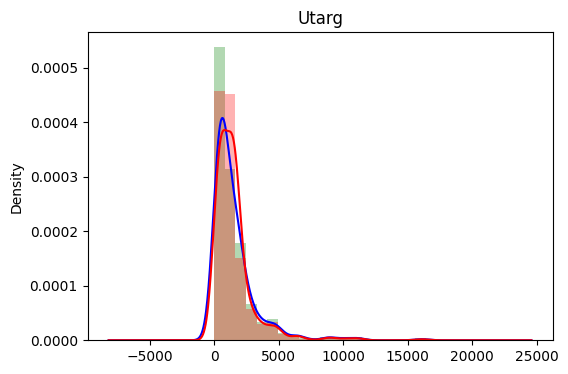

In [69]:
compare_distributions(df_brak['Utarg'], df_filled_brak['Utarg'], bins)

In [70]:
df_filled_brak['Utarg'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 799 entries, 0 to 798
Series name: Utarg
Non-Null Count  Dtype  
--------------  -----  
799 non-null    float64
dtypes: float64(1)
memory usage: 6.4 KB


In [71]:
df_brak['Utarg'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 799 entries, 0 to 798
Series name: Utarg
Non-Null Count  Dtype  
--------------  -----  
679 non-null    float64
dtypes: float64(1)
memory usage: 6.4 KB


**Zadanie 4**  

Bazując na przykładach z punktu 2 na zbiorze `zamowienia.csv` policz:

* 4.1 Średnią wartość zamówienia dla każdego kraju.
* 4.2 Średnią wartość zamówienia dla każdego roku, a następnie miesiąca (grupowanie dwustopniowe).
* 4.3 Liczbę zamówień, którą złożył każdy sprzedawca w danym roku.
* 4.4 Nazwę sprzedawcy z każdego kraju, którego sumaryczny utarg był najwyższy.
* 4.5 Sumę utargu w każdym kwartale (uwzględnij również rok), i posortuj od wartości najwyższych.

In [72]:
#4.1 Średnią wartość zamówienia dla każdego kraju.
srednia_kraju = df.groupby('Kraj').agg({'Utarg': 'mean'})
print(srednia_kraju)

              Utarg
Kraj               
Niemcy  1532.528236
Polska  1550.376326


In [73]:
df['Data zamowienia'].str[:4]

0      2003
1      2003
2      2003
3      2003
4      2003
       ... 
794    2005
795    2005
796    2005
797    2005
798    2005
Name: Data zamowienia, Length: 799, dtype: object

In [74]:
# 4.2 Średnią wartość zamówienia dla każdego roku, a następnie miesiąca (grupowanie dwustopniowe).
srednia_wart_zamowienia_rok = df.groupby([df['Data zamowienia'].str[:4],df['Data zamowienia'].str[5:7]]).agg({'Utarg': 'mean'})
srednia_wart_zamowienia_rok

Utarg
Data zamowienia Data zamowienia             
2003            07               1218.251176
                08               1097.598696
                09                858.577143
                10               1456.390000
                11               1973.045000
                12               1443.086875
2004            01               1914.425000
                02               1164.535926
                03               1484.822187
                04               1053.214667
                05               1999.229687
                06               1669.432667
                07               1211.127097
                08               1562.998889
                09               1329.139737
                10               2064.032778
                11               1123.419722
                12               1632.980000
2005            01               1487.635357
                02               2132.384815
                03               1157.157910
                04               1931.107297
                05               1155.370000

In [75]:
#4.3 Liczbę zamówień, którą złożył każdy sprzedawca w danym roku.
liczba_zamowien_sprzedawcy_rok = df.groupby([df['Data zamowienia'].str[:4], 'Sprzedawca']).agg({'idZamowienia': 'count'})
liczba_zamowien_sprzedawcy_rok

idZamowienia
Data zamowienia Sprzedawca              
2003            Callahan              17
                Davolio               23
                Dudek                  5
                Fuller                14
                King                  11
                Kowalski              10
                Leverling             18
                Peacock               31
                Sowiński              14
2004            Callahan              55
                Davolio               56
                Dudek                 18
                Fuller                41
                King                  34
                Kowalski              19
                Leverling             67
                Peacock               78
                Sowiński              31
2005            Callahan              27
                Davolio               38
                Dudek                 18
                Fuller                37
                King                  22
                Kowalski              13
                Leverling             40
                Peacock               42
                Sowiński              20

In [81]:
#4.4 Nazwę sprzedawcy z każdego kraju, którego sumaryczny utarg był najwyższy.
liders = df.groupby(['Kraj', 'Sprzedawca']).agg({'Utarg': 'sum'})
liders.nlargest(2, 'Utarg')

Utarg
Kraj   Sprzedawca           
Niemcy Peacock     225763.68
       Leverling   201196.27

In [76]:
df.head(5)

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90


Kwartały:

- I kwartał → styczeń, luty, marzec
- II kwartał → kwiecień, maj, czerwiec
- III kwartał → lipiec, sierpień, wrzesień
- IV kwartał → październik, listopad, grudzień

In [89]:
#4.5 Sumę utargu w każdym kwartale (uwzględnij również rok), i posortuj od wartości najwyższych.
df['Data zamowienia'] = pd.to_datetime(df['Data zamowienia'])
df['Kwartal'] = df['Data zamowienia'].dt.quarter
df['Rok'] = df['Data zamowienia'].dt.year
kwartal = df.groupby(['Kwartal', 'Rok']).agg({'Utarg':'sum'}).sort_values('Utarg', ascending=False)
kwartal

Utarg
Kwartal Rok            
1       2005  275985.94
4       2004  175168.55
2       2005  149834.16
        2004  145654.77
3       2004  144320.21
1       2004  144047.23
4       2003  129331.38
3       2003   63985.16